# Modelamiento supervisado — riesgo crediticio

Entrena y compara modelos para predecir `Pago_atiempo`. Los datos llegan del
componente `src/ft_engineering.py` (limpieza, features y split ya definidos allí).
Por el desbalance ~20:1, la evaluación se centra en la clase minoritaria (no pago):
recall, precisión, F1, AUC-ROC y AUC-PR; el accuracy se reporta solo como referencia.

In [6]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raiz = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.append(str(raiz))

from src.ft_engineering import (cargar_datos, limpiar, crear_features,
                                construir_preprocesador, split_datos, OBJETIVO)

df = crear_features(limpiar(cargar_datos()))
X_train, X_test, y_train, y_test = split_datos(df)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (8610, 23) | Test: (2153, 23)


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix)


def build_model(estimador, X_train, y_train):
    """Arma el pipeline preprocesador + estimador y lo entrena.

    El preprocesador se ajusta DENTRO del pipeline, solo con train:
    la imputacion y el escalado no ven nunca el test (sin fuga de datos).
    """
    modelo = Pipeline([
        ("preprocesador", construir_preprocesador(X_train)),
        ("clasificador", estimador),
    ])
    modelo.fit(X_train, y_train)
    return modelo


def summarize_classification(modelo, X_test, y_test, nombre="modelo"):
    """Calcula las metricas de evaluacion sobre la clase minoritaria (no pago = 0).

    pos_label=0: el evento de interes es NO pagar a tiempo, el raro (~5%).
    Es la misma logica de sensibilidad/especificidad con el evento como positivo.
    """
    y_pred = modelo.predict(X_test)
    # probabilidad de la clase 0 (no pago) para las AUC
    proba_no_pago = modelo.predict_proba(X_test)[:, list(modelo.classes_).index(0)]

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_no_pago": precision_score(y_test, y_pred, pos_label=0),
        "recall_no_pago": recall_score(y_test, y_pred, pos_label=0),
        "f1_no_pago": f1_score(y_test, y_pred, pos_label=0),
        "auc_roc": roc_auc_score(y_test == 0, proba_no_pago),
        "auc_pr": average_precision_score(y_test == 0, proba_no_pago),
    }

In [8]:
from sklearn.linear_model import LogisticRegression

log_reg = build_model(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    X_train, y_train)

resultado_lr = summarize_classification(log_reg, X_test, y_test, "Regresión logística")
pd.DataFrame([resultado_lr]).round(4)

,modelo,accuracy,precision_no_pago,recall_no_pago,f1_no_pago,auc_roc,auc_pr
0,Regresión logística,0.6568,0.077,0.5686,0.1357,0.6699,0.1192


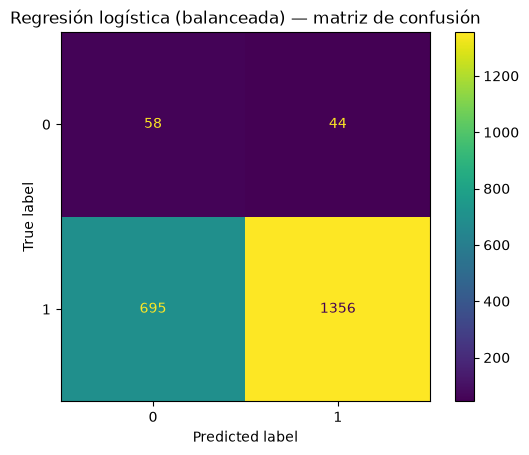

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test)
plt.title("Regresión logística (balanceada) — matriz de confusión")
plt.show()

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

candidatos = {
    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

resultados = [resultado_lr]
modelos = {"Regresión logística": log_reg}

for nombre, est in candidatos.items():
    m = build_model(est, X_train, y_train)
    modelos[nombre] = m
    resultados.append(summarize_classification(m, X_test, y_test, nombre))

tabla = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla

,accuracy,precision_no_pago,recall_no_pago,f1_no_pago,auc_roc,auc_pr
modelo,,,,,,
Regresión logística,0.6568,0.0770,0.5686,0.1357,0.6699,0.1192
Árbol de decisión,0.6043,0.0680,0.5784,0.1216,0.5785,0.0650
Random Forest,0.9526,0.5000,0.0196,0.0377,0.6436,0.1378
Gradient Boosting,0.9512,0.2857,0.0196,0.0367,0.6691,0.1196


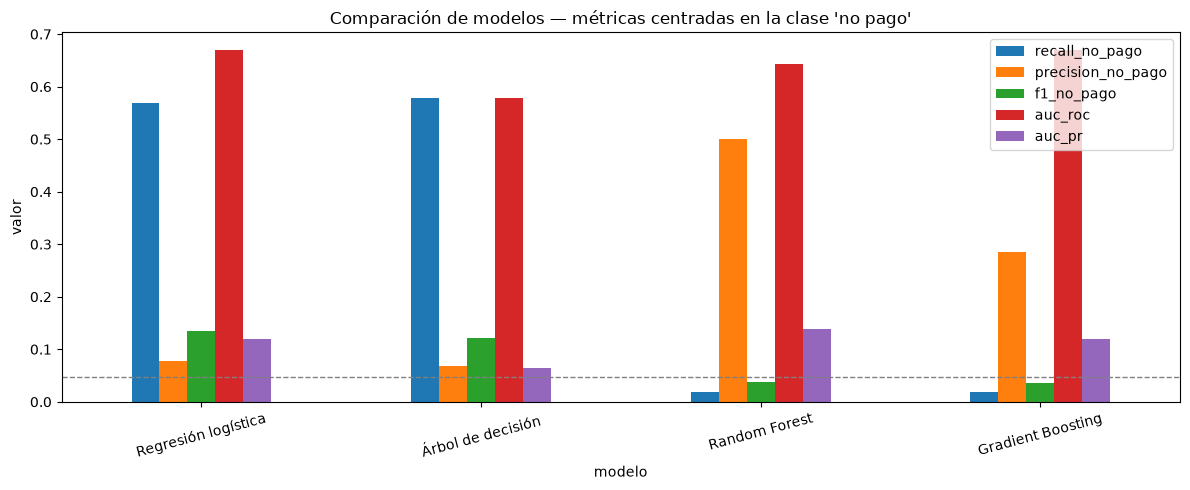

In [11]:
metricas = ["recall_no_pago", "precision_no_pago", "f1_no_pago", "auc_roc", "auc_pr"]
tabla[metricas].plot(kind="bar", figsize=(12, 5))
plt.title("Comparación de modelos — métricas centradas en la clase 'no pago'")
plt.ylabel("valor")
plt.xticks(rotation=15)
plt.axhline(y_test.eq(0).mean(), color="gray", ls="--", lw=1)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

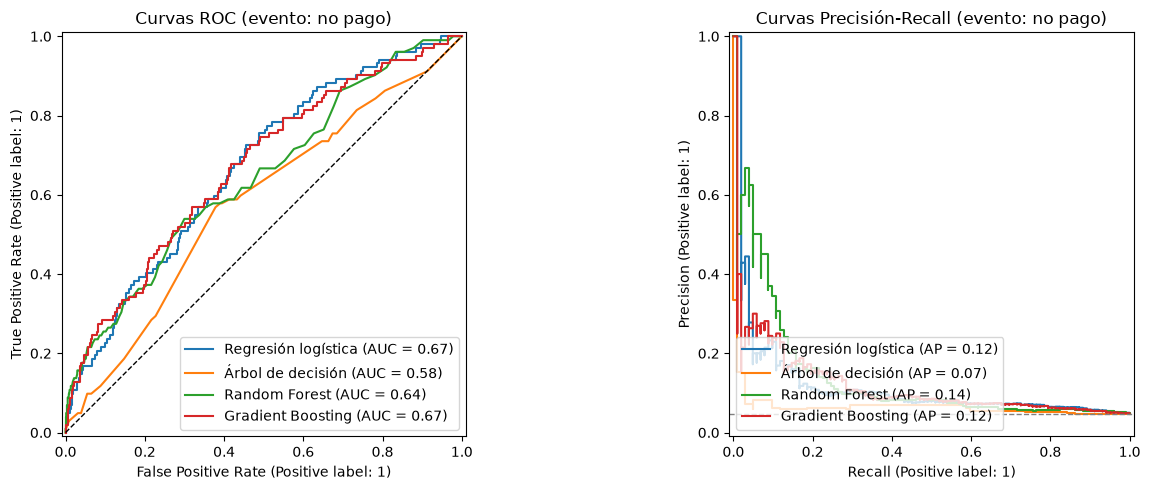

In [12]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for nombre, m in modelos.items():
    proba = m.predict_proba(X_test)[:, list(m.classes_).index(0)]
    RocCurveDisplay.from_predictions(y_test == 0, proba, name=nombre, ax=ax1)
    PrecisionRecallDisplay.from_predictions(y_test == 0, proba, name=nombre, ax=ax2)
ax1.plot([0, 1], [0, 1], "k--", lw=1)
ax1.set_title("Curvas ROC (evento: no pago)")
ax2.axhline(y_test.eq(0).mean(), color="gray", ls="--", lw=1)
ax2.set_title("Curvas Precisión-Recall (evento: no pago)")
plt.tight_layout()
plt.show()

## Selección del modelo

**1. El accuracy engaña con clases desbalanceadas.** Random Forest y Gradient
Boosting alcanzan ~0.95 de accuracy, prácticamente el mismo valor que obtendría
un modelo trivial que predijera "todos pagan" (la prevalencia de pago es 95.25%).
Ese accuracy alto convive con un recall de no-pago de 0.02: aciertan globalmente
porque ignoran casi por completo la clase que interesa detectar. Por eso la
comparación se centra en las métricas de la clase minoritaria y en las áreas
bajo las curvas.

**2. Umbral vs. capacidad de ranking.** Las métricas dependientes del umbral
(precisión, recall, F1) evalúan al modelo con el corte por defecto de 0.5; las
AUC evalúan cómo ordena el riesgo, independiente del corte. Con esa distinción,
Random Forest y Gradient Boosting no son malos modelos sino modelos mal
"umbralizados": su AUC-ROC (~0.64–0.67) y en especial el AUC-PR del Random
Forest (0.138, el mejor de la tabla y ~2.9 veces la prevalencia de 0.047)
muestran que sí capturan señal, pero con el umbral estándar casi nunca emiten
la alerta. El árbol de decisión, en cambio, es genuinamente débil: su AUC-PR
(0.065) apenas supera la prevalencia.

**3. Modelo seleccionado: regresión logística con `class_weight="balanced"`.**
Es el mejor modelo al umbral operativo: mayor F1 de no-pago (0.136), recall de
0.57 (detecta más de la mitad de los morosos) y AUC-ROC empatado en el máximo
(0.67). El costo es una precisión de 0.077 —de cada 100 alertas, ~8 son morosos
reales—, consecuencia esperable de la baja prevalencia del evento y aceptable
si el uso del modelo es priorizar gestión de cobranza preventiva, no rechazar
créditos automáticamente. A igualdad práctica de desempeño, se prefiere además
por interpretabilidad: sus coeficientes son log-odds y permiten explicar cada
alerta, algo relevante en decisiones de crédito.

**4. Mejora identificada para la siguiente iteración.** Ajustar el umbral de
decisión del Random Forest (y del boosting) sobre la curva Precisión-Recall,
en lugar de usar 0.5: su ventaja en AUC-PR sugiere que, con el corte adecuado,
podría superar a la logística. También queda pendiente la validación cruzada
para confirmar la estabilidad del ranking de modelos.